In [ ]:
%%capture
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(mnist_train_images, mnist_train_labels), (mnist_test_images, mnist_test_labels) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    train_images = mnist_train_images.reshape(mnist_train_images.shape[0], 1, 28, 28)
    test_images = mnist_test_images.reshape(mnist_test_images.shape[0], 1, 28, 28)
    input_shape = (1, 28, 28)
else:
    train_images = mnist_train_images.reshape(mnist_train_images.shape[0], 28, 28, 1)
    test_images = mnist_test_images.reshape(mnist_test_images.shape[0], 28, 28, 1)
    input_shape = (28, 28, 1)

train_images = train_images.astype('float32')
test_images = test_images.astype('float32')
train_images /= 255
test_images /= 255

train_labels = tensorflow.keras.utils.to_categorical(mnist_train_labels, 10)
test_labels = tensorflow.keras.utils.to_categorical(mnist_test_labels, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


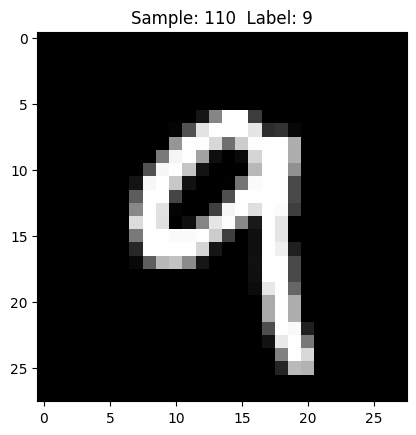

In [3]:
print(train_labels[110])
label = train_labels[110].argmax(axis=0)
image = train_images[110].reshape([28, 28])
plt.title('Sample: %d  Label: %d' % (110, label))
plt.imshow(image, cmap='gray')
plt.show()

In [4]:
model = Sequential()
model.add(Conv2D(32,
                 kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape))

model.add(Conv2D(64,
                 kernel_size=(3, 3),
                 activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128,
                activation='relu'))

model.add(Dropout(0.5))
model.add(Dense(10,
                activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(loss='categorical_crossentropy',
              optimizer="rmsprop",
              metrics=['accuracy'])

In [6]:
results = model.fit(train_images,
                    train_labels,
                    batch_size=32,
                    epochs=10,
                    verbose=2,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1875/1875 - 12s - 7ms/step - accuracy: 0.9431 - loss: 0.1847 - val_accuracy: 0.9825 - val_loss: 0.0524
Epoch 2/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9757 - loss: 0.0829 - val_accuracy: 0.9824 - val_loss: 0.0507
Epoch 3/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9786 - loss: 0.0731 - val_accuracy: 0.9816 - val_loss: 0.0603
Epoch 4/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9812 - loss: 0.0649 - val_accuracy: 0.9871 - val_loss: 0.0397
Epoch 5/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9816 - loss: 0.0624 - val_accuracy: 0.9890 - val_loss: 0.0360
Epoch 6/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9832 - loss: 0.0587 - val_accuracy: 0.9870 - val_loss: 0.0424
Epoch 7/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9842 - loss: 0.0576 - val_accuracy: 0.9888 - val_loss: 0.0356
Epoch 8/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9840 - loss: 0.0572 - val_accuracy: 0.9876 - val_loss: 0.0383
Epoch 9/10
1875/1875 - 10s - 5ms/step - accuracy: 0.9850 - loss: 0.0552 - val_accuracy: 0.9869 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step


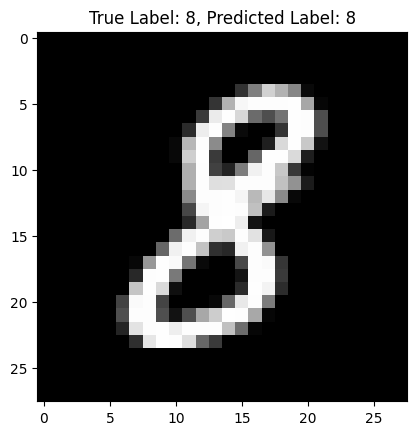

In [ ]:
prediction = model.predict(test_images[110].reshape(1, 28, 28, 1))

predicted_label = np.argmax(prediction)

true_label = np.argmax(test_labels[110])

image = test_images[110].reshape([28, 28])
plt.imshow(image, cmap='gray')
plt.title(f'True Label: {true_label}, Predicted Label: {predicted_label}')
plt.show()